# Lab 6: API, Online Data Extraction/Scraping by Python

In [2]:
import requests
import json
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx

In [3]:
def get_data(url):
    response = requests.get(url)
    data = response.json()
    return data

## 1. Get the location of sensors

In [4]:
url = 'https://api.glasgow.gov.uk/traffic/v1/movement/sites'
data = get_data(url)

#Convert dict to df
data_dict = {}
data_dict['id'] = [each_record['siteId'] for each_record in data]
data_dict['description'] = [each_record['from']['description'] for each_record in data]
data_dict['latitude'] = [each_record['from']['lat'] for each_record in data]
data_dict['longitude'] = [each_record['from']['long'] for each_record in data]
sensors_df = pd.DataFrame.from_dict(data_dict)
sensors_df

,id,description,latitude,longitude
0,GH020A_B,Gallowgate west to Sword St,55.8543754827825,-4.217259197086495
1,GJ3301_D,Carmunnock Rd southbound,55.821736212748405,-4.2561270616272875
2,GH020A_A,Gallowgate east to Sword St,55.85539015389372,-4.225769520669405
3,GJ3301_C,Carmunnock Rd northbound to Kings Park Avenue,55.81925458152306,-4.255696036412074
4,GJ3301_B,Kings Park Ave westbound to Carmunnock Rd,55.820288451422314,-4.250775113480551
...,...,...,...,...
1270,GL1851_S,PRW from tweedsmuir w/b,55.845768181789424,-4.355396486903399
1271,GJ011A_V,Aikenhead Road northbound to Dixon Rd,55.83169902330712,-4.248512176194785
1272,GA4771_V,Glassford Street Northbound,55.857648657839455,-4.24934030262111
1273,GJ011A_T,Aikenhead Road southbound to Dixon Rd,55.835226792673474,-4.248747790943153


## Map the sensors

In [6]:
# Create a GeoDataFrame
sensors_df["geometry"] = gpd.points_from_xy(sensors_df["longitude"], sensors_df["latitude"])
# set coordinates 
sensors_gdf = gpd.GeoDataFrame(sensors_df, crs="epsg:4326")
# #Reproject
sensors_gdf = sensors_gdf.to_crs("epsg:3857")
sensors_gdf

,id,description,latitude,longitude,geometry
0,GH020A_B,Gallowgate west to Sword St,55.8543754827825,-4.217259197086495,POINT (-469463.146 7529480.384)
1,GJ3301_D,Carmunnock Rd southbound,55.821736212748405,-4.2561270616272875,POINT (-473789.897 7523009.916)
2,GH020A_A,Gallowgate east to Sword St,55.85539015389372,-4.225769520669405,POINT (-470410.511 7529681.621)
3,GJ3301_C,Carmunnock Rd northbound to Kings Park Avenue,55.81925458152306,-4.255696036412074,POINT (-473741.916 7522518.175)
4,GJ3301_B,Kings Park Ave westbound to Carmunnock Rd,55.820288451422314,-4.250775113480551,POINT (-473194.121 7522723.035)
...,...,...,...,...,...
1270,GL1851_S,PRW from tweedsmuir w/b,55.845768181789424,-4.355396486903399,POINT (-484840.519 7527773.530)
1271,GJ011A_V,Aikenhead Road northbound to Dixon Rd,55.83169902330712,-4.248512176194785,POINT (-472942.212 7524984.386)
1272,GA4771_V,Glassford Street Northbound,55.857648657839455,-4.24934030262111,POINT (-473034.399 7530129.564)
1273,GJ011A_T,Aikenhead Road southbound to Dixon Rd,55.835226792673474,-4.248747790943153,POINT (-472968.441 7525683.655)


#### Filter the sensors

In [7]:
borough_uk = gpd.read_file('data/district_borough_unitary.shp')
borough_gla = borough_uk.loc[borough_uk['Name']=='Glasgow City'].to_crs("epsg:3857")

sensor_join = gpd.sjoin(sensors_gdf, borough_gla, how ='inner', op ='within')

/Users/qzhao/opt/anaconda3/envs/geospatial/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3493: FutureWarning: The `op` parameter is deprecated and will be removed in a future release. Please use the `predicate` parameter instead.
  if await self.run_code(code, result, async_=asy):


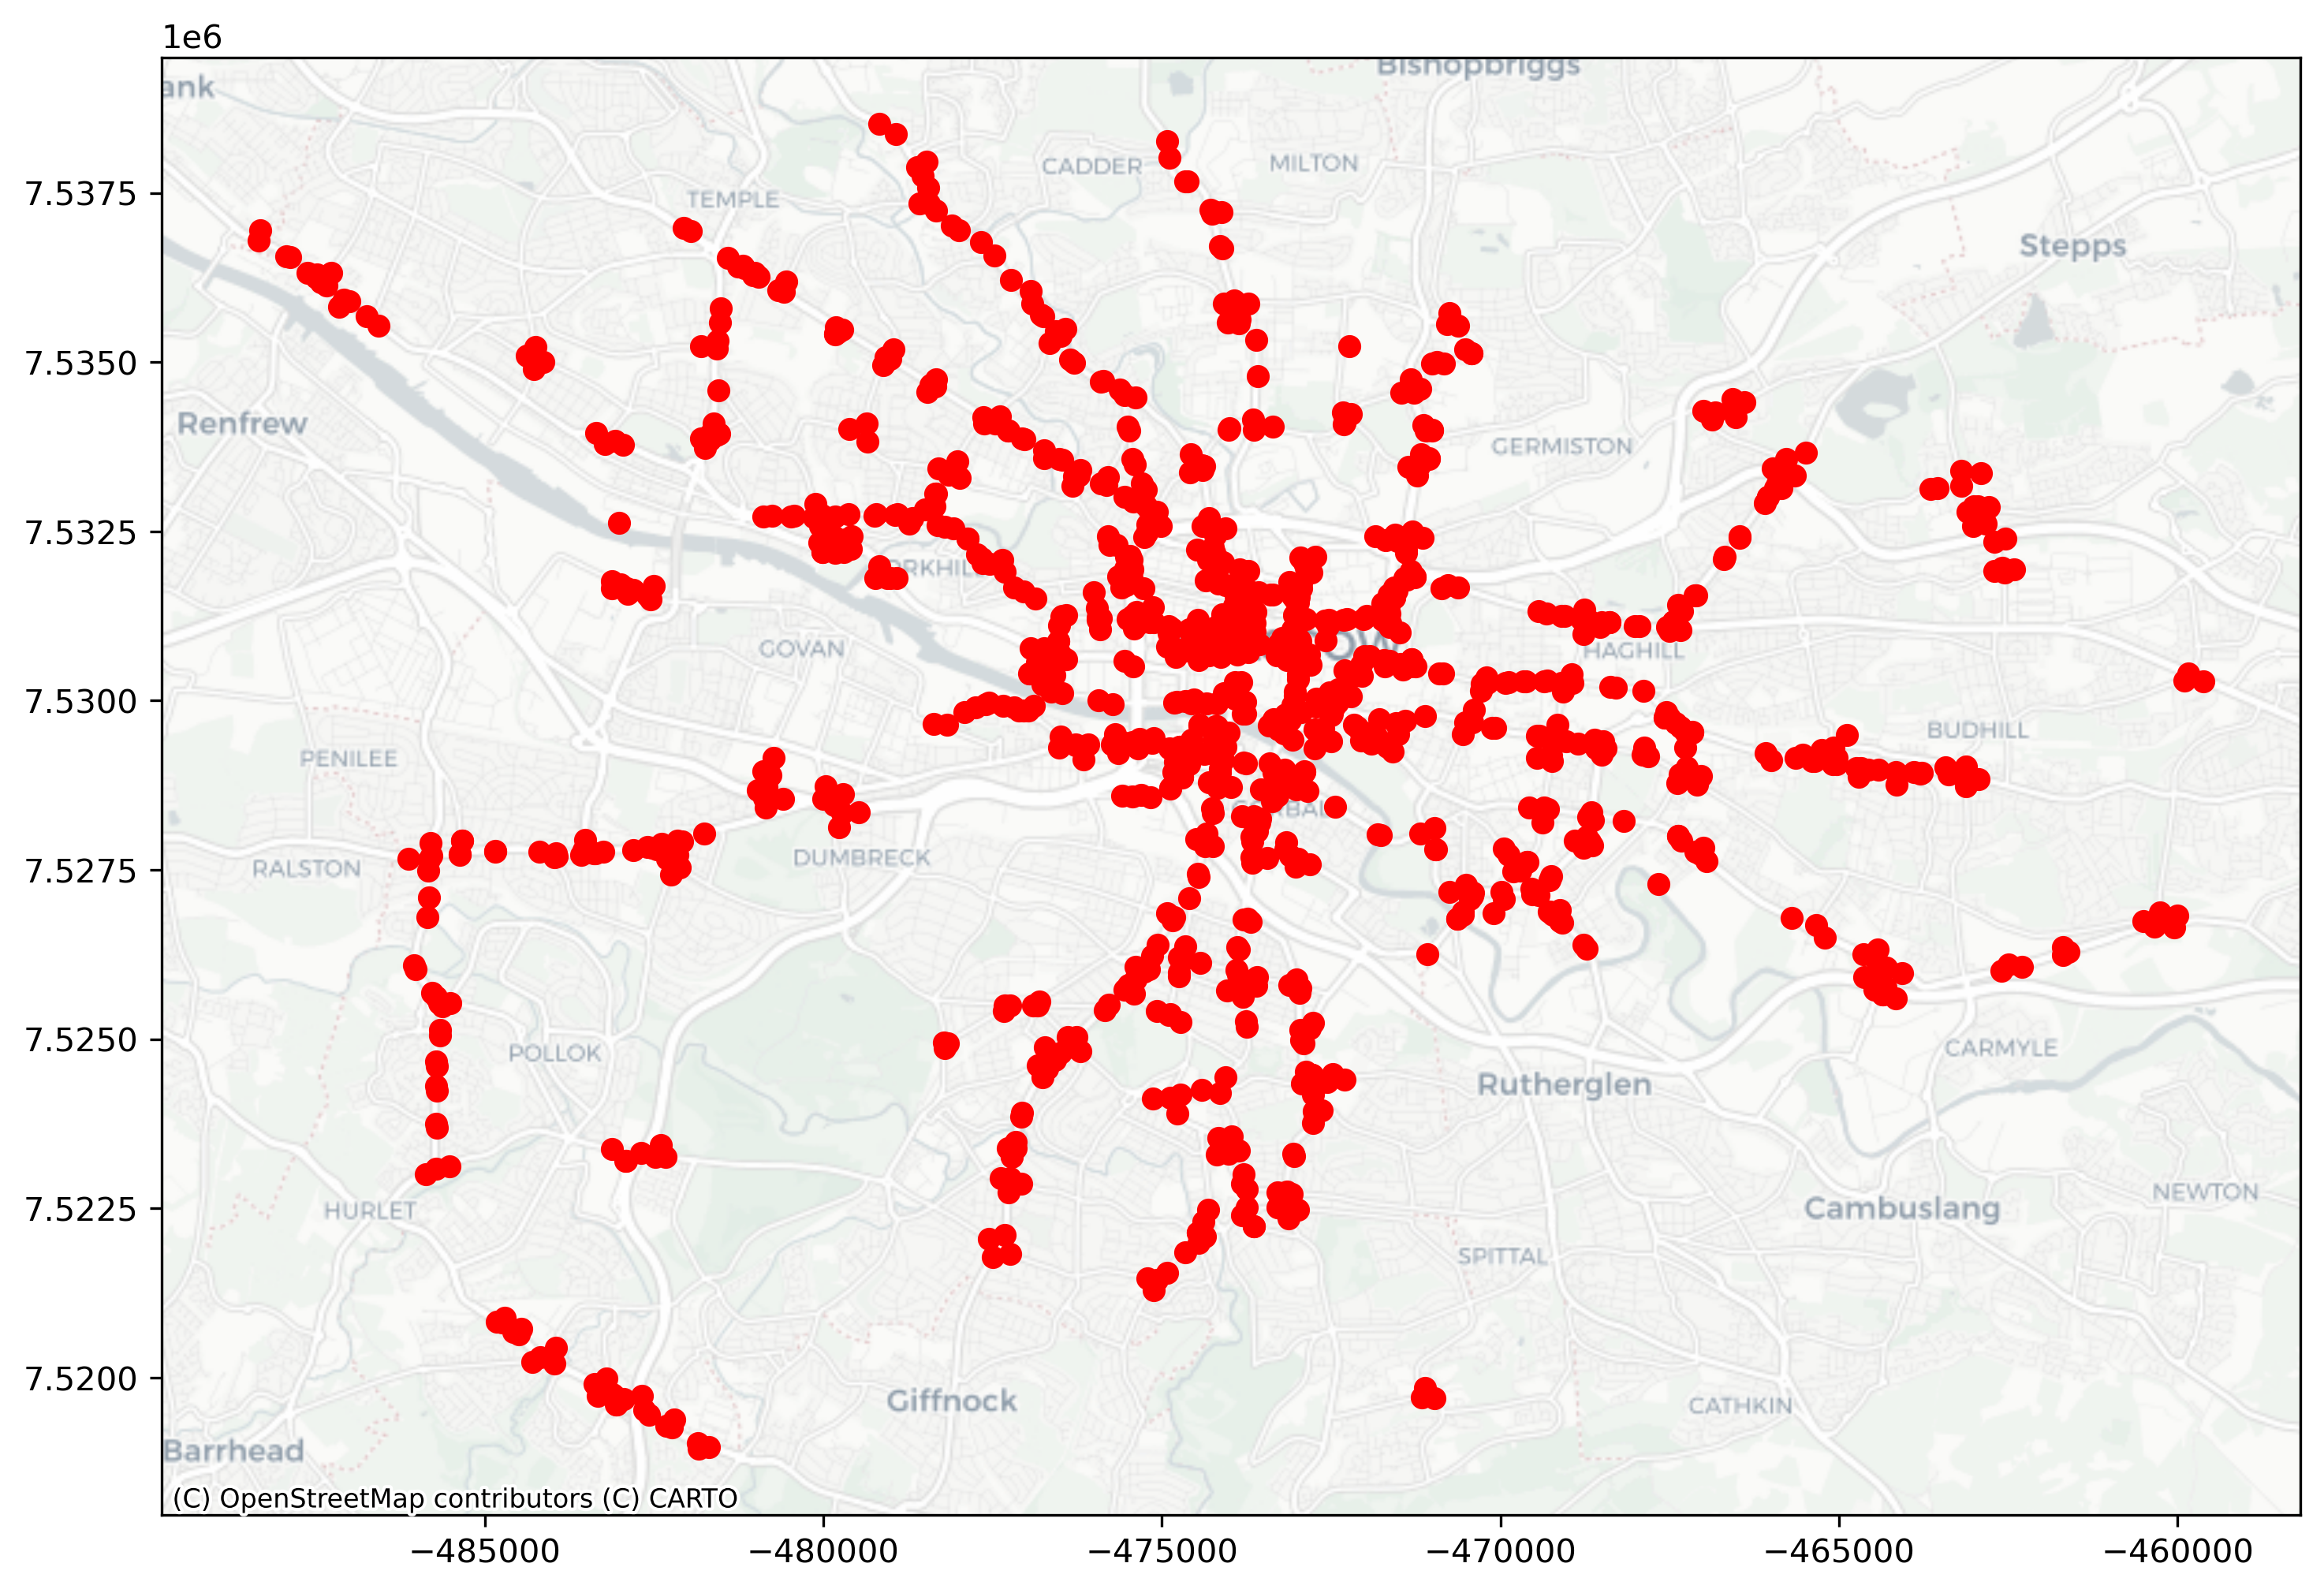

In [8]:
fig, ax = plt.subplots(figsize=(12,8), dpi=300) 
#Plot the data
sensor_join.plot(color = 'red',ax=ax)
#Add basemap
ctx.add_basemap(ax, crs="EPSG:3857", source=ctx.providers.CartoDB.Positron)

In [9]:
sensor_join.explore(color="red",tiles='cartodbpositron', tooltip=['id','description','latitude','longitude'], 
                    width=750, height=500)